# Capstone progress: wavelet-guided deepfake detection

Reproduction of Ghosh & Naskar, *WGN: Wavelet-Guided Network for Efficient and Generalised Deepfake Detection* (CVPRW 2026).

This notebook is the status a director can read on GitHub. GitHub shows the output from the last time each cell ran.

Training used four parts of the official Kaggle DFDC release. Two more datasets were downloaded into `Dataset/` and are processed later in this notebook: Celeb-DF v2 and HiDF. Those cells crop faces and then score the DFDC checkpoints already saved under `runs/`. A crop manifest or a score file that is already present is reused, so running the notebook again does not repeat that work.

**What this project can claim.** The comparison is the wavelet model (WGN) against the same backbone with the wavelet gate removed, on one identical DFDC split, two seeds. Metrics are frame-level. Celeb-DF and HiDF scores are those same DFDC checkpoints tested on another set. They are not the paper's Table 2, and the paper's 70.41% DFDC figure is a FaceForensics++ model tested on DFDC, so it is not a target here.


## 1. Where the numbers come from


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

def find_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "runs").is_dir() and (candidate / "REPORT.md").is_file():
            return candidate
    raise SystemExit("Run this notebook from the project directory (the folder that contains runs/ and REPORT.md).")

ROOT = find_root()
RUNS = ROOT / "runs"

def run_cmd(cmd: list[str]) -> None:
    """Run a project script with the local vendor packages. Print its log."""
    env = os.environ.copy()
    env["PYTHONPATH"] = os.pathsep.join(
        [str(ROOT / "vendor"), str(ROOT), env.get("PYTHONPATH", "")]
    )
    print("+", " ".join(cmd), flush=True)
    proc = subprocess.Popen(
        cmd,
        cwd=ROOT,
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="", flush=True)
    code = proc.wait()
    if code != 0:
        raise SystemExit(f"command failed with exit code {code}: {' '.join(cmd)}")

# An interrupted job is kept for the log, but it is not a finished result.
# Tags with "_on_" are a saved checkpoint scored on another dataset, not a training run.
finished = []
external = []
incomplete = []
for metrics_path in sorted(RUNS.glob("*/metrics.json")):
    tag = metrics_path.parent.name
    if "partial" in tag:
        incomplete.append(tag + " (interrupted, ignored)")
        continue
    metrics = json.loads(metrics_path.read_text())
    test = (metrics.get("test") or {}).get("all")
    scored = bool(test and test.get("acc") is not None)
    if not scored:
        incomplete.append(tag + " (no test score yet)")
        continue
    if "_on_" in tag:
        external.append(tag)
    else:
        finished.append(tag)

print("Project:", ROOT.name)
print("In-domain DFDC runs:", ", ".join(finished) if finished else "none")
print("Cross-dataset scores:", ", ".join(external) if external else "none yet")
if incomplete:
    print("Not included:", "; ".join(incomplete))


Project: Capstone Project
In-domain DFDC runs: baseline_dfdc_s0, baseline_dfdc_s1, wgn_dfdc_s0, wgn_dfdc_s1
Cross-dataset scores: baseline_dfdc_on_celebdf_s0, baseline_dfdc_on_celebdf_s1, wgn_dfdc_on_celebdf_s0, wgn_dfdc_on_celebdf_s1
Not included: wgn_dfdc_s0_partial (interrupted, ignored)


## 2. Data that was actually trained on

DFDC parts 00–03. Each fake stays in the same split as the real clip it was made from, so the same face never appears on both sides of a split. Real clips contribute more frames than fake clips so the two classes are close to equal.


In [2]:
audit_path = ROOT / "data" / "dfdc" / "verify_report.json"
if not audit_path.is_file():
    print("Audit file is not in this checkout (data/ is not committed).")
    print("The saved output above this message, from the last full run, is the audit the crops passed.")
else:
    audit = json.loads(audit_path.read_text())
    print(f"{'split':<8} {'real frames':>12} {'fake frames':>12} {'real/fake':>10}")
    for split, bal in audit["class_balance"].items():
        print(f"{split:<8} {bal['real']:12d} {bal['fake']:12d} {bal['ratio']:10.3f}")
    print()
    checks = audit["acceptance"]
    labels = {
        "class_ratio_within_1.05": "class balance within 5%",
        "detection_fail_lt_2pct": "face-detection failures under 2%",
        "all_crops_256_rgb_png": "crops are 256x256 RGB PNG",
        "zero_clip_id_overlap": "no clip id shared across splits",
        "train_split_non_empty": "training split is non-empty",
    }
    for key, label in labels.items():
        print(f"  {'PASS' if checks.get(key) else 'FAIL'}  {label}")
    print(f"  clip failures logged: {audit['failures']['n']}")
    print(f"  identity-overlap errors: {len(audit['overlap_errors'])}")


split     real frames  fake frames  real/fake
train           39414        39315      1.003
val              8020         7899      1.015
test             8333         8267      1.008

  PASS  class balance within 5%
  PASS  face-detection failures under 2%
  PASS  crops are 256x256 RGB PNG
  PASS  no clip id shared across splits
  PASS  training split is non-empty
  clip failures logged: 0
  identity-overlap errors: 0


## 3. Face crops

Sixty-four random training crops per class. Each cell should be one face. Profiles and dark frames are normal for DFDC.


**Real**

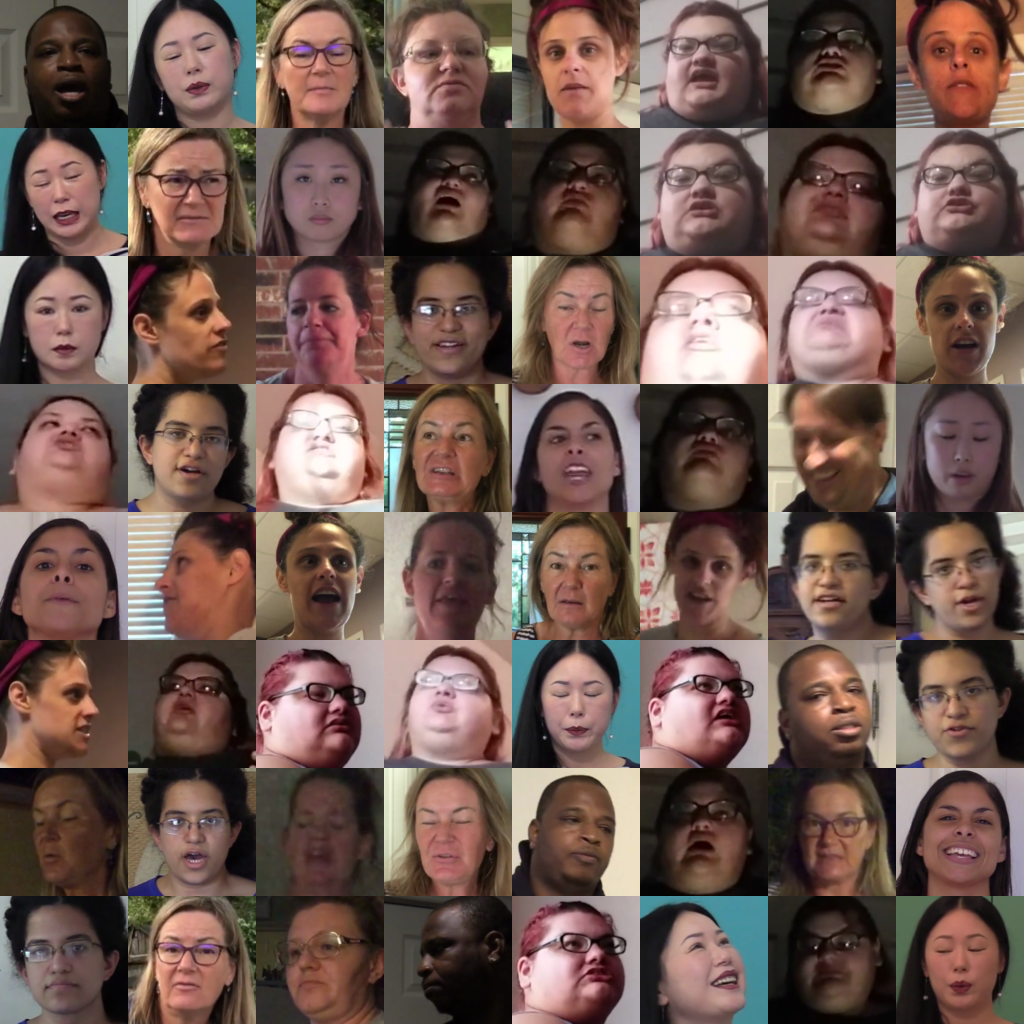

**Fake**

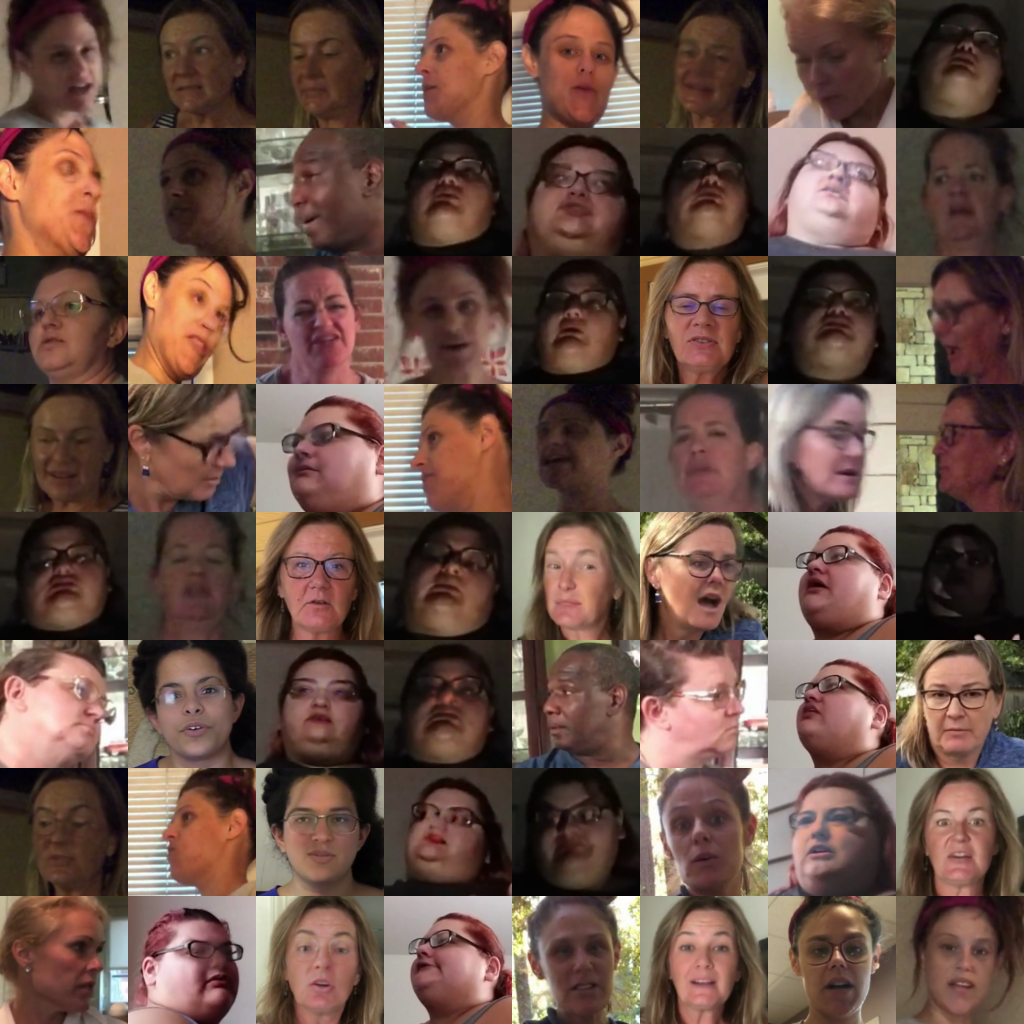

In [3]:
from IPython.display import display, Image, Markdown

for label, filename in (("Real", "real.png"), ("Fake", "fake.png")):
    path = ROOT / "contact_sheets" / filename
    display(Markdown(f"**{label}**"))
    if path.is_file():
        display(Image(filename=str(path)))
    else:
        print(f"Missing {path}")


## 4. Training results

Both models use MobileViT-S, Adam at 1e-4, 25 epochs, batch 32, horizontal flip only. The backbone run is the same network with the wavelet gate removed. The checkpoint kept for the test score is the one with the highest validation accuracy.


In [4]:
def load_result(tag: str) -> dict:
    folder = RUNS / tag
    config = json.loads((folder / "config.json").read_text())
    metrics = json.loads((folder / "metrics.json").read_text())
    best = metrics["best"]
    test = metrics["test"]["all"]
    return {
        "tag": tag,
        "model": "Backbone only" if config["args"].get("no_wgsa") else "WGN",
        "seed": config["seed"],
        "params_m": config["num_params_m"],
        "device": config["device"],
        "best_epoch": best["epoch"],
        "val_acc": best["acc"],
        "val_auc": best["auc"],
        "test_acc": test["acc"],
        "test_auc": test["auc"],
        "n_test": test["n"],
        "epochs": metrics["epochs"],
    }

results = [load_result(tag) for tag in finished]
results.sort(key=lambda r: (r["seed"], r["model"] != "WGN"))

header = f"{'model':<16} {'seed':>4} {'epoch':>5} {'val acc':>8} {'val auc':>8} {'test acc':>9} {'test auc':>9} {'n':>7}"
print(header)
print("-" * len(header))
for r in results:
    print(
        f"{r['model']:<16} {r['seed']:4d} {r['best_epoch']:5d} "
        f"{r['val_acc']:8.2f} {r['val_auc']:8.2f} "
        f"{r['test_acc']:9.2f} {r['test_auc']:9.2f} {r['n_test']:7d}"
    )
print()
print("epoch = the saved checkpoint (best validation accuracy). Scores are frame-level percent.")
print(f"parameters: WGN {next(r['params_m'] for r in results if r['model']=='WGN'):.2f} M, "
      f"backbone {next(r['params_m'] for r in results if r['model']=='Backbone only'):.2f} M. "
      f"device: {results[0]['device']}.")


model            seed epoch  val acc  val auc  test acc  test auc       n
-------------------------------------------------------------------------
WGN                 0    22    96.46    99.46     96.99     99.51   16600
Backbone only       0    22    96.54    99.48     97.09     99.48   16600
WGN                 1    21    96.31    99.25     96.83     99.52   16600
Backbone only       1    19    96.47    99.46     96.96     99.58   16600

epoch = the saved checkpoint (best validation accuracy). Scores are frame-level percent.
parameters: WGN 5.76 M, backbone 4.94 M. device: mps.


## 5. Validation accuracy across training

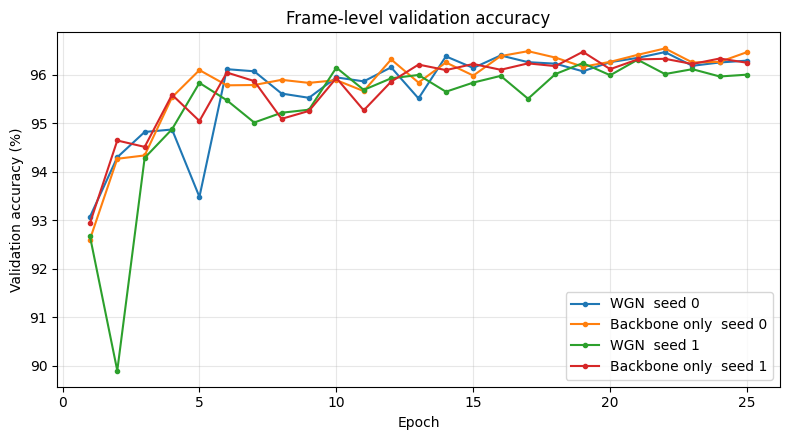

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for r in results:
    epochs = [e["epoch"] for e in r["epochs"]]
    acc = [e["val_acc"] for e in r["epochs"]]
    ax.plot(epochs, acc, marker="o", markersize=3, label=f"{r['model']}  seed {r['seed']}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation accuracy (%)")
ax.set_title("Frame-level validation accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 6. What the two seeds say

In [6]:
from collections import defaultdict

by_seed = defaultdict(dict)
for r in results:
    by_seed[r["seed"]][r["model"]] = r

print("Test set, WGN minus backbone. Positive means the wavelet model is ahead.")
print()
acc_gaps, auc_gaps = [], []
for seed in sorted(by_seed):
    pair = by_seed[seed]
    if "WGN" not in pair or "Backbone only" not in pair:
        print(f"seed {seed}: incomplete pair, skipped")
        continue
    d_acc = pair["WGN"]["test_acc"] - pair["Backbone only"]["test_acc"]
    d_auc = pair["WGN"]["test_auc"] - pair["Backbone only"]["test_auc"]
    acc_gaps.append(d_acc)
    auc_gaps.append(d_auc)
    acc_winner = "WGN" if d_acc > 0 else "backbone" if d_acc < 0 else "tie"
    auc_winner = "WGN" if d_auc > 0 else "backbone" if d_auc < 0 else "tie"
    print(f"seed {seed}: accuracy {d_acc:+.2f} ({acc_winner})    AUC {d_auc:+.2f} ({auc_winner})")

if acc_gaps:
    print()
    print(f"mean accuracy gap {sum(acc_gaps)/len(acc_gaps):+.2f}")
    print(f"mean AUC gap      {sum(auc_gaps)/len(auc_gaps):+.2f}")
    if all(g < 0 for g in acc_gaps):
        print("On accuracy, the backbone is ahead on every finished seed.")
    elif all(g > 0 for g in acc_gaps):
        print("On accuracy, WGN is ahead on every finished seed.")
    else:
        print("Accuracy does not favor the same model on every seed.")


Test set, WGN minus backbone. Positive means the wavelet model is ahead.

seed 0: accuracy -0.10 (backbone)    AUC +0.03 (WGN)
seed 1: accuracy -0.13 (backbone)    AUC -0.06 (backbone)

mean accuracy gap -0.12
mean AUC gap      -0.01
On accuracy, the backbone is ahead on every finished seed.


## 7. Extra datasets that were downloaded

FaceForensics++ was not available. Two other sets were downloaded into `Dataset/` and are used only as extra tests of the checkpoints above. Nothing in this section retrains the model.

- **Celeb-DF v2.** Official test list only (`List_of_testing_videos.txt`). Label 1 is real and label 0 is fake. 340 of the 518 test videos are fake, so a model that always answers "fake" scores 65.6% accuracy.
- **HiDF.** `Real-vid/` and `Fake-vid/` sit next to the DFDC parts. The two classes are about equal, so a constant guess is about 50% accuracy.


In [7]:
def count_videos(folder: Path) -> int:
    if not folder.is_dir():
        return 0
    total = 0
    for ext in (".mp4", ".avi", ".mkv", ".mov"):
        total += sum(1 for _ in folder.rglob(f"*{ext}"))
    return total

downloads = ROOT / "Dataset"
print("Download folder:", downloads if downloads.is_dir() else "not in this checkout")
print()

celeb = downloads / "Celeb-DF-v2"
print("Celeb-DF v2")
if not celeb.is_dir():
    print("  not downloaded at Dataset/Celeb-DF-v2")
else:
    for name in ("Celeb-real", "YouTube-real", "Celeb-synthesis"):
        print(f"  {name:<16} {count_videos(celeb / name):6d} videos")
    test_list = celeb / "List_of_testing_videos.txt"
    if test_list.is_file():
        real = fake = 0
        for line in test_list.read_text().splitlines():
            parts = line.split()
            if len(parts) >= 2 and parts[0] == "1":
                real += 1
            elif len(parts) >= 2 and parts[0] == "0":
                fake += 1
        print(f"  official test list {real + fake} videos ({real} real, {fake} fake)")
    else:
        print("  official test list is missing")

print()
print("HiDF")
real_dir = downloads / "Real-vid"
fake_dir = downloads / "Fake-vid"
if not real_dir.is_dir() and not fake_dir.is_dir():
    print("  not downloaded (expected Dataset/Real-vid and Dataset/Fake-vid)")
else:
    print(f"  Real-vid         {count_videos(real_dir):6d} videos")
    print(f"  Fake-vid         {count_videos(fake_dir):6d} videos")


Download folder: /Users/ronaldayala/Documents/GitHub/Capstone Project/Dataset

Celeb-DF v2
  Celeb-real          590 videos
  YouTube-real        300 videos
  Celeb-synthesis    5639 videos
  official test list 518 videos (178 real, 340 fake)

HiDF
  Real-vid           4361 videos
  Fake-vid           4361 videos


## 8. Crop faces from those videos

Same crop used for DFDC training: MTCNN, 10 frames per clip, 256 pixels. Face detection stays on the CPU. Celeb-DF uses only the official test list. HiDF uses every video in `Real-vid/` and `Fake-vid/`.

If `preprocess_manifest.json` is already under `data/celebdf` or `data/hidf`, that dataset is not cropped again.


In [8]:
CROP_JOBS = [
    ("Celeb-DF v2", "celebdf", "Dataset/Celeb-DF-v2", "data/celebdf"),
    ("HiDF", "hidf", "Dataset", "data/hidf"),
]

for title, dataset, root_rel, out_rel in CROP_JOBS:
    manifest_path = ROOT / out_rel / "preprocess_manifest.json"
    print(title)
    if manifest_path.is_file():
        print("  crops already saved; not cropping again")
    else:
        source = ROOT / root_rel
        if not source.is_dir():
            print(f"  download not found at {root_rel}, and no saved crops")
            print()
            continue
        run_cmd([
            sys.executable, "scripts/preprocess_external.py",
            "--dataset", dataset,
            "--root", root_rel,
            "--out", out_rel,
            "--device", "cpu",
        ])
    if not manifest_path.is_file():
        print("  no manifest written")
        print()
        continue
    manifest = json.loads(manifest_path.read_text())
    print(f"  videos listed     {manifest['n_videos']}")
    print(f"  frames saved      {manifest['n_frames_saved']}")
    print(f"  frames per clip   {manifest['n_frames_per_clip']}")
    print(f"  crop size         {manifest['size']}")
    print(f"  clips with no face {manifest['n_failures']}")
    failures_path = ROOT / out_rel / "failures.json"
    if failures_path.is_file() and manifest["n_failures"]:
        failures = json.loads(failures_path.read_text())
        for item in failures:
            print(f"    {item.get('category')}  {item.get('clip')}  {item.get('reason')}")
    counts = {}
    for label in ("real", "fake"):
        folder = ROOT / out_rel / "test" / label
        counts[label] = sum(1 for p in folder.rglob("*.png")) if folder.is_dir() else 0
    total = counts["real"] + counts["fake"]
    if total:
        majority = max(counts.values()) / total * 100
        print(f"  frames on disk    {counts['real']} real, {counts['fake']} fake")
        print(f"  always-majority accuracy {majority:.2f}%")
    print()


Celeb-DF v2
  crops already saved; not cropping again
  videos listed     518
  frames saved      5180
  frames per clip   10
  crop size         256
  clips with no face 0
  frames on disk    1780 real, 3400 fake
  always-majority accuracy 65.64%

HiDF
  crops already saved; not cropping again
  videos listed     8722
  frames saved      86975
  frames per clip   10
  crop size         256
  clips with no face 7
    real  c11687  detection_failed
    real  c11977  detection_failed
    real  c12946  detection_failed
    real  c14518  detection_failed
    fake  c11687_c10015  detection_failed
    fake  c11977_c11613  detection_failed
    fake  c12946_c20754  detection_failed


  frames on disk    43448 real, 43527 fake
  always-majority accuracy 50.05%



## 9. Score the saved DFDC checkpoints

These cells do not train. Each saved checkpoint is scored on the crops from section 8. A score file that is already present is left alone.


In [9]:
CHECKPOINTS = [
    ("wgn_dfdc_s0", 0, False),
    ("baseline_dfdc_s0", 0, True),
    ("wgn_dfdc_s1", 1, False),
    ("baseline_dfdc_s1", 1, True),
]

SCORE_SETS = [
    ("Celeb-DF v2 official test", "data/celebdf", "celebdf"),
    ("HiDF", "data/hidf", "hidf"),
]


def eval_tag(train_tag: str, slug: str, seed: int) -> str:
    return train_tag.replace(f"_s{seed}", f"_on_{slug}_s{seed}")


def saved_test(tag: str):
    path = RUNS / tag / "metrics.json"
    if not path.is_file():
        return None
    test = (json.loads(path.read_text()).get("test") or {}).get("all")
    if not test or test.get("acc") is None:
        return None
    return test


for title, data_rel, slug in SCORE_SETS:
    data_dir = ROOT / data_rel
    pending = []
    for train_tag, seed, no_wgsa in CHECKPOINTS:
        tag = eval_tag(train_tag, slug, seed)
        if saved_test(tag) is not None:
            continue
        if not (data_dir / "test").is_dir():
            print(f"{title}: crops not found at {data_rel}/test, skipped")
            pending = None
            break
        ckpt = RUNS / train_tag / "best.pt"
        if not ckpt.is_file():
            print(f"{title}: missing checkpoint {ckpt.relative_to(ROOT)}")
            continue
        pending.append((data_rel, tag, ckpt, seed, no_wgsa))
    if pending:
        print(f"{title}: scoring {len(pending)} checkpoint(s). Saved scores are reused, not recomputed.")
        for data_rel, tag, ckpt, seed, no_wgsa in pending:
            cmd = [
                sys.executable, "-m", "wgn.train",
                "--data", data_rel,
                "--tag", tag,
                "--eval-only",
                "--ckpt", str(ckpt.relative_to(ROOT)),
                "--seed", str(seed),
                "--workers", "4",
            ]
            if no_wgsa:
                cmd.append("--no-wgsa")
            run_cmd(cmd)
    elif pending == []:
        print(f"{title}: all four checkpoints already scored")


Celeb-DF v2 official test: all four checkpoints already scored
HiDF: scoring 4 checkpoint(s). Saved scores are reused, not recomputed.
+ /Library/Frameworks/Python.framework/Versions/3.14/bin/python3 -m wgn.train --data data/hidf --tag wgn_dfdc_on_hidf_s0 --eval-only --ckpt runs/wgn_dfdc_s0/best.pt --seed 0 --workers 4


eval-only: skipping dataset load for train/val


params: 5.76 M


loaded checkpoint runs/wgn_dfdc_s0/best.pt


test/fake             acc 55.86 | auc 59.48  (frame-level, n=86975)


...

eval-only: skipping dataset load for train/val


params: 4.94 M


loaded checkpoint runs/baseline_dfdc_s1/best.pt


test/fake             acc 57.11 | auc 61.36  (frame-level, n=86975)


test/all              acc 57.11 | auc 61.36  (frame-level, n=86975)


## 10. What those extra tests say

Accuracy on Celeb-DF has to be read against the 65.6% fake-majority base rate. HiDF is nearly balanced. AUC is the number that is comparable across the two sets. A positive gap means the wavelet model is ahead of the backbone.



Celeb-DF v2 official test
always-majority accuracy 65.64%  (1780 real frames, 3400 fake frames)
model            seed      acc      auc       n
-----------------------------------------------
WGN                 0    62.97    56.40    5180
Backbone only       0    65.27    64.15    5180
WGN                 1    62.16    56.09    5180
Backbone only       1    64.71    59.99    5180
seed 0: accuracy -2.30    AUC -7.75
seed 1: accuracy -2.55    AUC -3.90



HiDF
always-majority accuracy 50.05%  (43448 real frames, 43527 fake frames)
model            seed      acc      auc       n
-----------------------------------------------
WGN                 0    55.86    59.48   86975
Backbone only       0    55.86    58.81   86975
WGN                 1    56.72    61.40   86975
Backbone only       1    57.11    61.36   86975
seed 0: accuracy +0.00    AUC +0.67
seed 1: accuracy -0.39    AUC +0.04


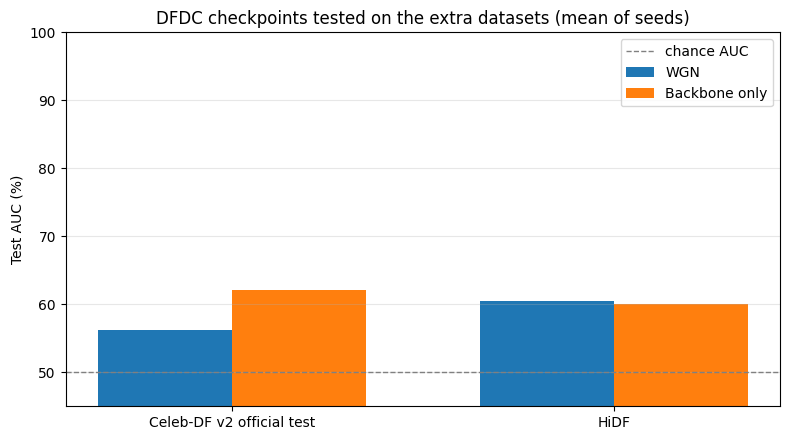

In [10]:
%matplotlib inline
def frame_counts(out_rel: str) -> dict:
    counts = {}
    for label in ("real", "fake"):
        folder = ROOT / out_rel / "test" / label
        counts[label] = sum(1 for p in folder.rglob("*.png")) if folder.is_dir() else 0
    return counts


rows = []
for title, data_rel, slug in SCORE_SETS:
    counts = frame_counts(data_rel)
    total = counts["real"] + counts["fake"]
    base = (max(counts.values()) / total * 100) if total else None
    print()
    print(title)
    if base is not None:
        print(f"always-majority accuracy {base:.2f}%  ({counts['real']} real frames, {counts['fake']} fake frames)")
    header = f"{'model':<16} {'seed':>4} {'acc':>8} {'auc':>8} {'n':>7}"
    print(header)
    print("-" * len(header))
    by_seed = {}
    for train_tag, seed, no_wgsa in CHECKPOINTS:
        tag = eval_tag(train_tag, slug, seed)
        model = "Backbone only" if no_wgsa else "WGN"
        test = saved_test(tag)
        if test is None:
            print(f"{model:<16} {seed:4d} {'—':>8} {'—':>8} {'—':>7}")
            continue
        print(f"{model:<16} {seed:4d} {test['acc']:8.2f} {test['auc']:8.2f} {test['n']:7d}")
        by_seed.setdefault(seed, {})[model] = test
        rows.append((title, model, seed, test["auc"]))
    for seed in sorted(by_seed):
        pair = by_seed[seed]
        if "WGN" in pair and "Backbone only" in pair:
            d_acc = pair["WGN"]["acc"] - pair["Backbone only"]["acc"]
            d_auc = pair["WGN"]["auc"] - pair["Backbone only"]["auc"]
            print(f"seed {seed}: accuracy {d_acc:+.2f}    AUC {d_auc:+.2f}")

if rows:
    import matplotlib.pyplot as plt
    from collections import defaultdict

    means = defaultdict(lambda: defaultdict(list))
    for title, model, seed, auc in rows:
        means[title][model].append(auc)
    labels = []
    for title, _, _ in SCORE_SETS:
        if title in means:
            labels.append(title)
    if labels:
        import numpy as np
        x = np.arange(len(labels))
        width = 0.35
        fig, ax = plt.subplots(figsize=(8, 4.5))
        for offset, model in ((-width / 2, "WGN"), (width / 2, "Backbone only")):
            vals = [sum(means[label][model]) / len(means[label][model]) for label in labels]
            ax.bar(x + offset, vals, width, label=model)
        ax.axhline(50, color="gray", linewidth=1, linestyle="--", label="chance AUC")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel("Test AUC (%)")
        ax.set_ylim(45, 100)
        ax.set_title("DFDC checkpoints tested on the extra datasets (mean of seeds)")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        plt.show()


## 11. Where the wavelet gate looks

This cell draws the maps. It uses the Apple GPU (`--device mps`) and the seed-0 wavelet checkpoint `runs/wgn_dfdc_s0/best.pt`. Two test frames per class. Columns are the input, the backbone features F, the gate A, the gated features F⊙A, Grad-CAM on the fused map, and that map over the face. A positive logit is a fake prediction.

If `figures/attention_manifest.json` already records `mps` and the three figures are on disk, the cell displays them and does not draw again.


In [ ]:
from IPython.display import display, Image, Markdown

ATTENTION_JOBS = [
    ("DFDC test. The checkpoint is confident and correct on these four frames.", "data/dfdc", "figures/attention_dfdc.png"),
    ("Celeb-DF official test. The same checkpoint labels the real frames as fake.", "data/celebdf", "figures/attention_celebdf.png"),
    ("HiDF. Real frames are also pushed toward fake.", "data/hidf", "figures/attention_hidf.png"),
]
manifest_path = ROOT / "figures" / "attention_manifest.json"
pngs_ready = all((ROOT / out_rel).is_file() for _, _, out_rel in ATTENTION_JOBS)
stamp = json.loads(manifest_path.read_text()) if manifest_path.is_file() else {}
if pngs_ready and stamp.get("device") == "mps":
    print("Attention maps already drawn on MPS; not drawing again.")
else:
    print("Drawing attention maps on MPS.")
    for _, data_rel, out_rel in ATTENTION_JOBS:
        run_cmd([
            sys.executable, "scripts/gradcam.py",
            "--ckpt", "runs/wgn_dfdc_s0/best.pt",
            "--data", data_rel,
            "--out", out_rel,
            "--device", "mps",
            "--per-class", "2",
        ])
    manifest_path.parent.mkdir(parents=True, exist_ok=True)
    manifest_path.write_text(json.dumps({
        "device": "mps",
        "ckpt": "runs/wgn_dfdc_s0/best.pt",
        "per_class": 2,
    }, indent=2))

for caption, _, out_rel in ATTENTION_JOBS:
    path = ROOT / out_rel
    display(Markdown(f"**{caption}**"))
    if path.is_file():
        display(Image(filename=str(path)))
    else:
        print(f"Missing {path}")


## 12. CBAM on the same DFDC split

This is ablation C2: the wavelet gate is replaced by CBAM attention. Same data, same 25 epochs, seed 0. `wgn.train` picks the device itself: CUDA, otherwise the Apple GPU (MPS), otherwise CPU. A finished score file is reused, so running the notebook again does not train a second time.


In [ ]:
def finished_test(tag: str):
    path = RUNS / tag / "metrics.json"
    if not path.is_file():
        return None
    test = (json.loads(path.read_text()).get("test") or {}).get("all")
    if not test or test.get("acc") is None:
        return None
    return test

cbam_tag = "cbam_dfdc_s0"
if finished_test(cbam_tag) is None:
    print("Training CBAM. The log line 'device' is written into runs/cbam_dfdc_s0/config.json.")
    run_cmd([
        sys.executable, "-m", "wgn.train",
        "--data", "data/dfdc",
        "--tag", cbam_tag,
        "--attention", "cbam",
        "--seed", "0",
        "--epochs", "25",
        "--workers", "4",
    ])
else:
    print(f"{cbam_tag}: already trained, not training again")

config_path = RUNS / cbam_tag / "config.json"
if config_path.is_file():
    config = json.loads(config_path.read_text())
    print(f"device {config.get('device')} | params {config.get('num_params_m'):.2f} M")

print()
header = f"{'model':<16} {'seed':>4} {'test acc':>9} {'test auc':>9}"
print(header)
print("-" * len(header))
for label, tag in (("WGN", "wgn_dfdc_s0"), ("Backbone only", "baseline_dfdc_s0"), ("CBAM", cbam_tag)):
    test = finished_test(tag)
    if test is None:
        print(f"{label:<16} {0:4d} {'—':>9} {'—':>9}")
        continue
    print(f"{label:<16} {0:4d} {test['acc']:9.2f} {test['auc']:9.2f}")


## 13. Not done yet

Sections 7–10 do not replace the paper's Table 2. Those published AUCs come from a model trained on FaceForensics++, which this project does not have.

- Table 1, in-domain FaceForensics++.
- Table 2, the published cross-dataset numbers (Celeb-DF 77.62, DFDC 70.41, WildDeepfake 68.65).
- Table 3, cross-manipulation. DFDC, Celeb-DF, and HiDF do not label the manipulation method.
- Table 6 rows other than the backbone comparison and the CBAM run in section 12. The HH-band ablation has not been trained.

Face cropping stays on the CPU. MTCNN's face detector fails on MPS, so section 8 passes `--device cpu` to that step only.
